# D-1 PERCOBAAN HISTOGRAM

In [2]:
import cv2 as cv
# from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt 
import numpy as np
import math
import os
import glob

Membuat histogram citra seperti berdasarkan flowchart di bawah ini : (Gunakan gambar lena.jpg)

<BarContainer object of 256 artists>

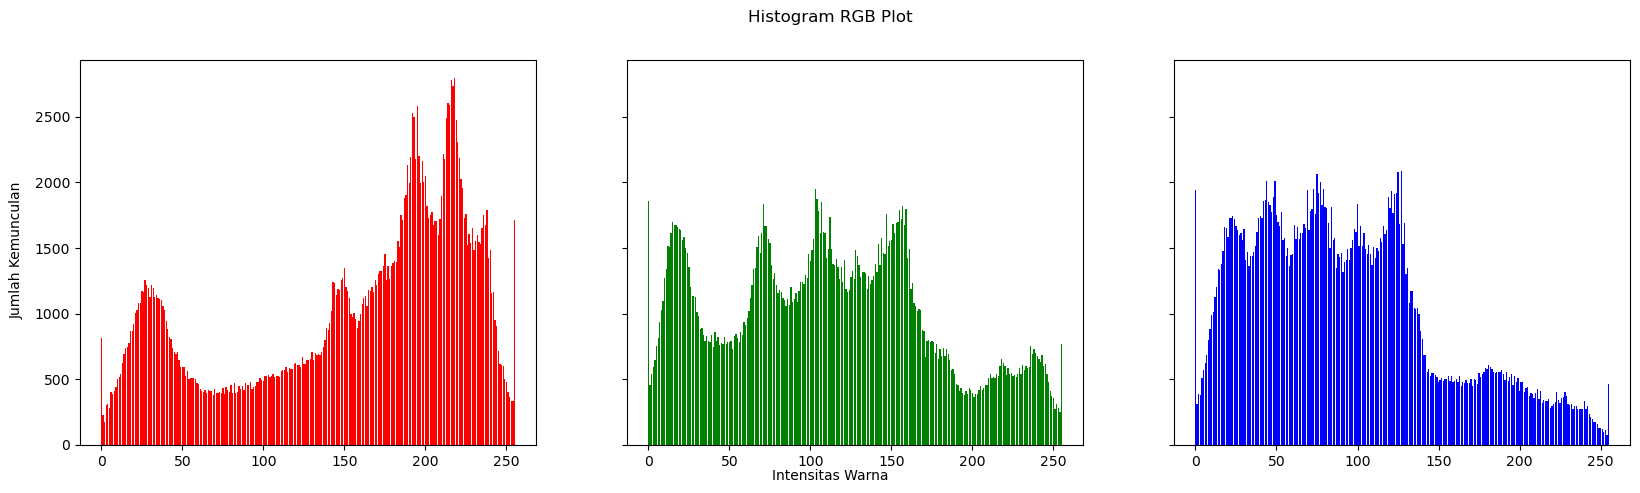

In [3]:
img = img = cv.imread('../images/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0, height):
    for x in range(0, width):
        red[img[y][x][0]] += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]] += 1
        
names = np.arange(256)
fig, axs = plt.subplots(1, 3 , figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB Plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')


## PERTANYAAN PRAKTIKUM D1

### 1. Buatlah histogram citra yang sama akan tetapi menggunakan library yang dimiliki oleh NumPy yaitu “histogram”. Bandingkan hasilnya. Apakah output muncul sama?

<BarContainer object of 256 artists>

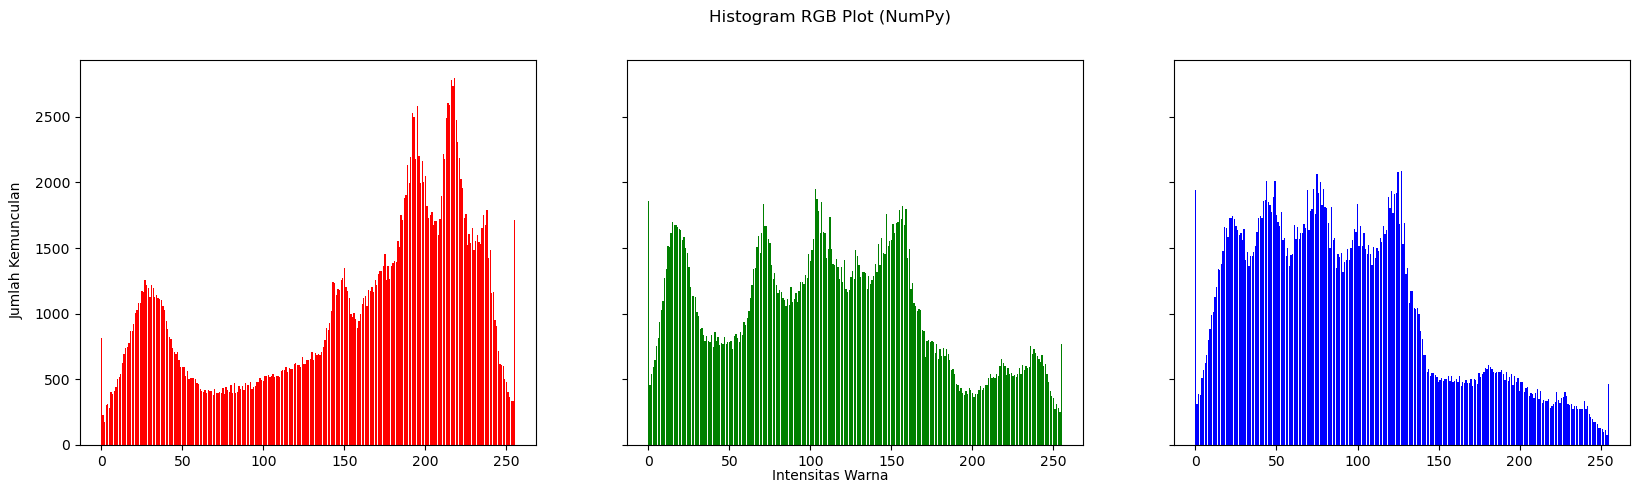

In [4]:
img2 = img2 = cv.imread('../images/lena.jpg')
img2 = cv.cvtColor(img2, cv.COLOR_BGR2RGB)

red2 = img2[:,:,0].ravel()
green2 = img2[:,:,1].ravel()
blue2 = img2[:,:,2].ravel()

hist_red, bins_red = np.histogram(red2, bins=256, range=(0,256))
hist_green, bins_green = np.histogram(green2, bins=256, range=(0,256))
hist_blue, bins_blue = np.histogram(blue2, bins=256, range=(0,256))

names = np.arange(256)
fig, axs = plt.subplots(1, 3 , figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB Plot (NumPy)')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, hist_red, color='red')
axs[1].bar(names, hist_green, color='green')
axs[2].bar(names, hist_blue, color='blue')

### 2. Buatlah histogram dengan menggunakan dengan menggunakan image KTM lama.jpg. Analisis distribusi intensitas dari histogram yang dihasilkan apakah gambar cenderung gelap, terang, atau kontras rendah.

<BarContainer object of 256 artists>

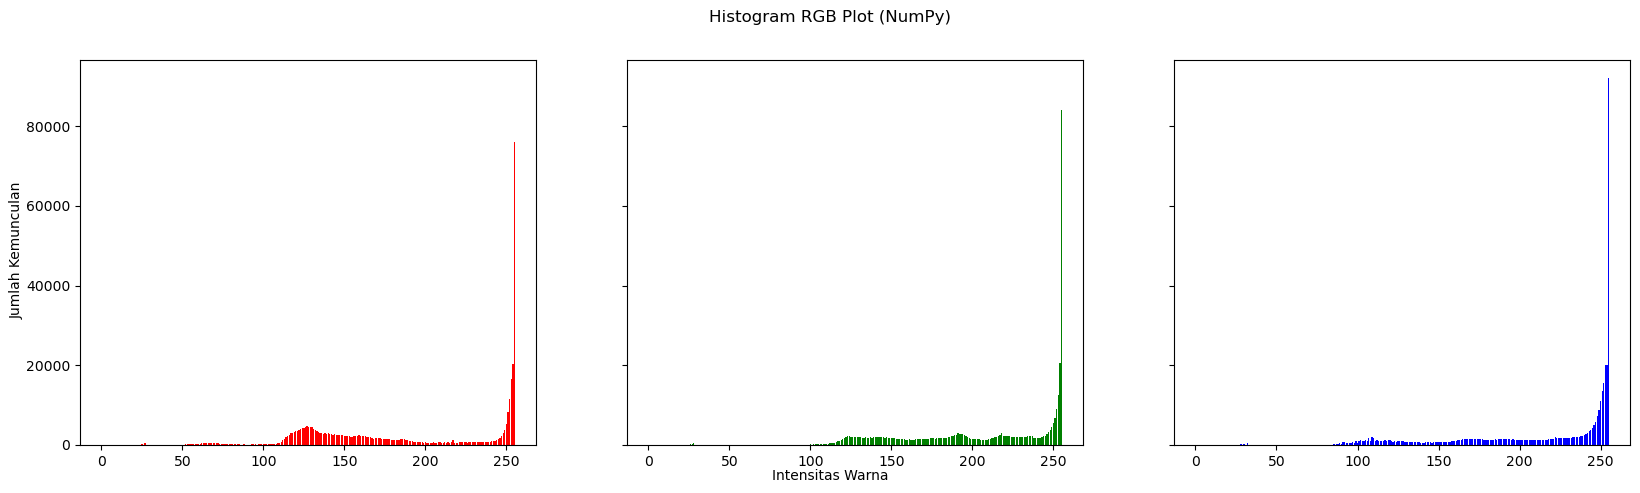

In [5]:
img3 = img3 = cv.imread('../images/KTM_lama.jpg')
img3 = cv.cvtColor(img3, cv.COLOR_BGR2RGB)

red2 = img3[:,:,0].ravel()
green2 = img3[:,:,1].ravel()
blue2 = img3[:,:,2].ravel()

hist_red, bins_red = np.histogram(red2, bins=256, range=(0,256))
hist_green, bins_green = np.histogram(green2, bins=256, range=(0,256))
hist_blue, bins_blue = np.histogram(blue2, bins=256, range=(0,256))

names = np.arange(256)
fig, axs = plt.subplots(1, 3 , figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB Plot (NumPy)')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, hist_red, color='red')
axs[1].bar(names, hist_green, color='green')
axs[2].bar(names, hist_blue, color='blue')

Penjelasan: Gambar KTM Lama.jpg cenderung terang dikarenakan pada histogram tinggi pada nilai sekitar 255, dan gambar tersebut termasuk kontras rendah dikarenakan persebaran histogramnya tidak merata.

# D-2 PERCOBAAN HISTOGRAM EQUALIZATION

### 1. Buatlah histogram citra seperti output histogram equalization dan juga tampilan gambar sebelum dan sesudah proses histogram equalization berikut berdasarkan flowchart di bawah ini : (Gunakan gambar lena_lc.jpg)

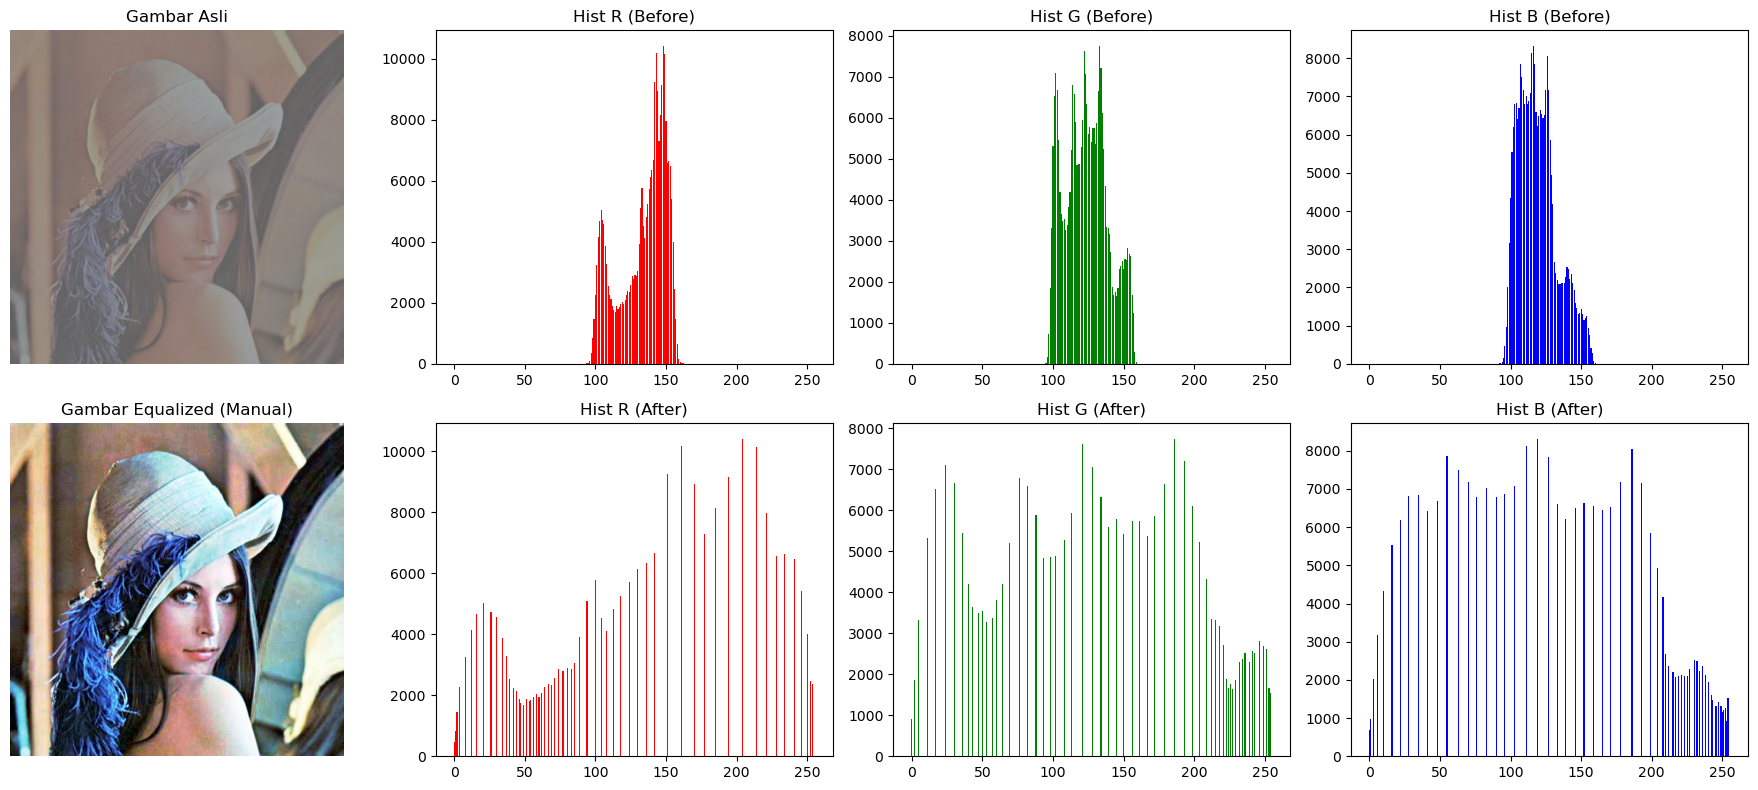

In [6]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

img = cv.imread('../images/lena_lc.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

def hist_eq(channel):
    hist, bins = np.histogram(channel.flatten(), bins=256, range=[0,256])
    cdf = hist.cumsum()
    
    cdf_normalized = (cdf - cdf.min()) * 255 / (cdf.max() - cdf.min())
    cdf_normalized = cdf_normalized.astype('uint8')
    
    equalized_channel = cdf_normalized[channel]
    return equalized_channel, hist, cdf_normalized

r_eq, hist_r, cdf_r = hist_eq(img[:,:,0])
g_eq, hist_g, cdf_g = hist_eq(img[:,:,1])
b_eq, hist_b, cdf_b = hist_eq(img[:,:,2])

equalized_img = cv.merge((r_eq, g_eq, b_eq))

hist_r_eq, bins_r_eq = np.histogram(r_eq.flatten(), bins=256, range=[0,256])
hist_g_eq, bins_g_eq = np.histogram(g_eq.flatten(), bins=256, range=[0,256])
hist_b_eq, bins_b_eq = np.histogram(b_eq.flatten(), bins=256, range=[0,256])

fig, axs = plt.subplots(2, 4, figsize=(18,8))

axs[0,0].imshow(img)
axs[0,0].set_title("Gambar Asli")
axs[0,0].axis("off")

axs[0,1].bar(np.arange(256), hist_r, color='red')
axs[0,1].set_title("Hist R (Before)")
axs[0,2].bar(np.arange(256), hist_g, color='green')
axs[0,2].set_title("Hist G (Before)")
axs[0,3].bar(np.arange(256), hist_b, color='blue')
axs[0,3].set_title("Hist B (Before)")

axs[1,0].imshow(equalized_img)
axs[1,0].set_title("Gambar Equalized (Manual)")
axs[1,0].axis("off")

axs[1,1].bar(np.arange(256), hist_r_eq, color='red')
axs[1,1].set_title("Hist R (After)")
axs[1,2].bar(np.arange(256), hist_g_eq, color='green')
axs[1,2].set_title("Hist G (After)")
axs[1,3].bar(np.arange(256), hist_b_eq, color='blue')
axs[1,3].set_title("Hist B (After)")

plt.tight_layout()
plt.show()

### 2. Setelah mengerjakan langkah no. 1, buatlah histogram citra yang sama akan tetapi menggunakan library yang dimiliki oleh CV2 yaitu “equalizeHist” seperti pada potongan kode berikut ini.

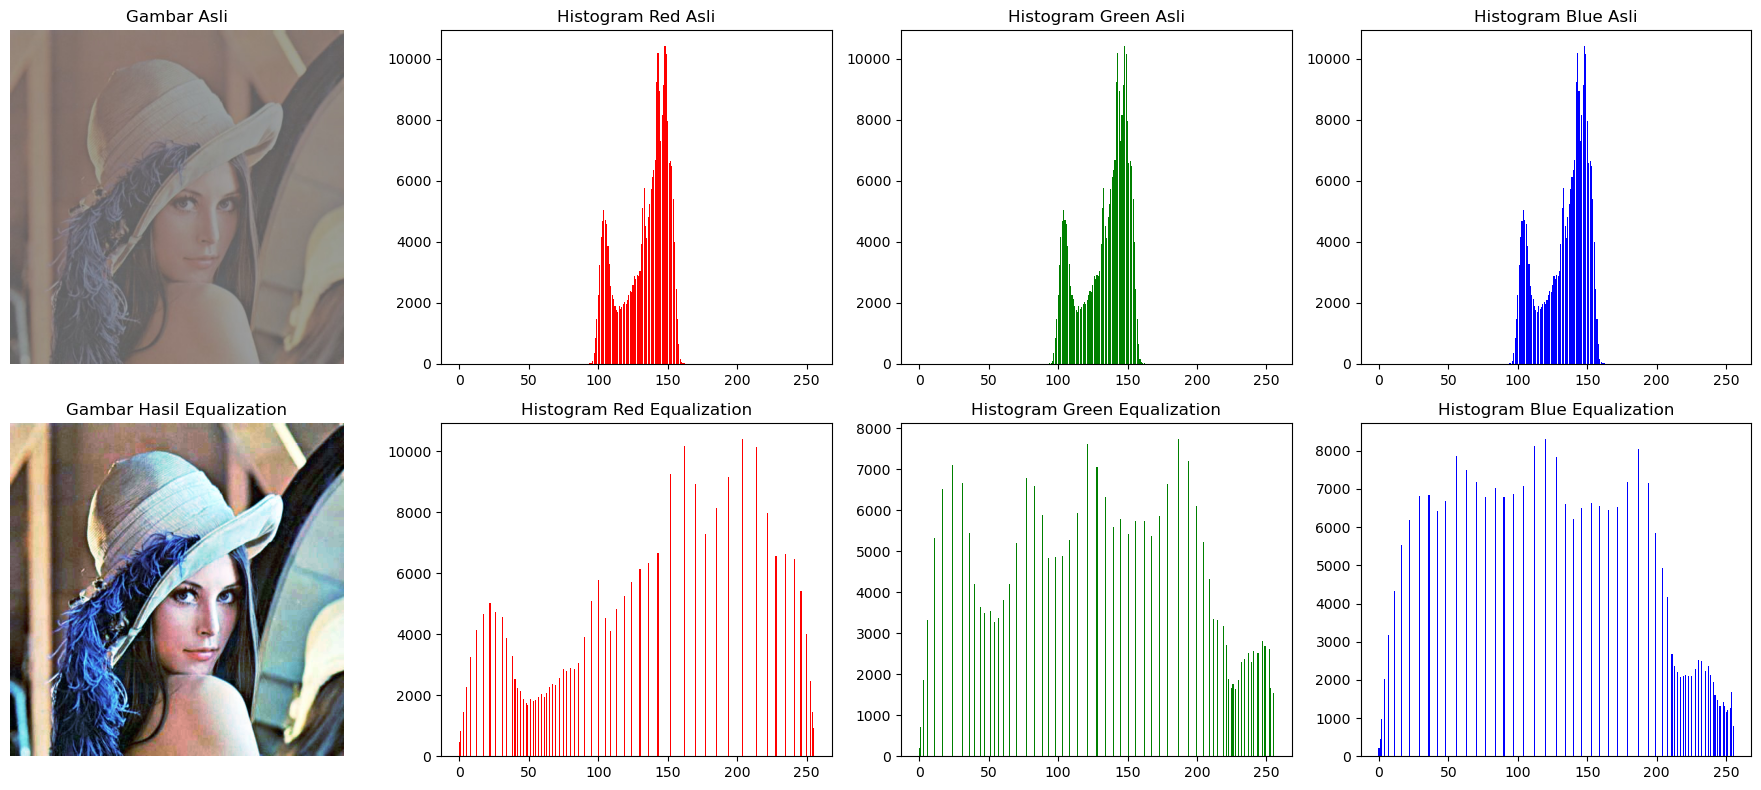

In [7]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

img_lena = img_lena = cv.imread('../images/lena_lc.jpg')
img_lena = cv.cvtColor(img_lena, cv.COLOR_BGR2RGB)

r, g, b = cv.split(img_lena)

r_eq = cv.equalizeHist(r)
g_eq = cv.equalizeHist(g)
b_eq = cv.equalizeHist(b)

img_lena_eq = cv.merge((r_eq, g_eq, b_eq))

hist_r, bins_r = np.histogram(r.ravel(), 256, [0,256])
hist_g, bins_g = np.histogram(g.ravel(), 256, [0,256])
hist_b, bins_b = np.histogram(b.ravel(), 256, [0,256])

hist_r_eq, bins_r_eq = np.histogram(r_eq.ravel(), 256, [0,256])
hist_g_eq, bins_g_eq = np.histogram(g_eq.ravel(), 256, [0,256])
hist_b_eq, bins_b_eq = np.histogram(b_eq.ravel(), 256, [0,256])


fig, axs = plt.subplots(2, 4, figsize=(18,8))

axs[0,0].imshow(img_lena)
axs[0,0].set_title("Gambar Asli")
axs[0,0].axis("off")

axs[0,1].bar(bins_r[:-1], hist_r, color='red')
axs[0,1].set_title("Histogram Red Asli")
axs[0,2].bar(bins_r[:-1], hist_r, color='green')
axs[0,2].set_title("Histogram Green Asli")
axs[0,3].bar(bins_r[:-1], hist_r, color='blue')
axs[0,3].set_title("Histogram Blue Asli")

axs[1,0].imshow(img_lena_eq)
axs[1,0].set_title("Gambar Hasil Equalization")
axs[1,0].axis("off")

axs[1,1].bar(bins_r_eq[:-1], hist_r_eq, color='red')
axs[1,1].set_title("Histogram Red Equalization")
axs[1,2].bar(bins_g_eq[:-1], hist_g_eq, color='green')
axs[1,2].set_title("Histogram Green Equalization")
axs[1,3].bar(bins_b_eq[:-1], hist_b_eq, color='blue')    
axs[1,3].set_title("Histogram Blue Equalization")

plt.tight_layout()
plt.show()


**Jawaban:** Output sama baik dengan cara manual maupun dengan ```cv.equalizeHist()```

## PERTANYAAN PRAKTIKUM D2

### 1. Perbandingan Citra Lena

#### a. Gunakan hasil histogram equalization pada citra lena.jpg.

#### b. Hitung nilai PSNR antara citra asli dan citra hasil equalization.

In [8]:
def calculate_psnr(img1, img2):
    mse = np.mean((img1.astype(np.float32) - img2.astype(np.float32)) ** 2)
    if mse == 0:
        return float('inf') 
    psnr = 10 * np.log10((255 ** 2) / mse)
    return psnr

psnr_value = calculate_psnr(img_lena, img_lena_eq)
print("PSNR antara citra asli dan equalization:", psnr_value, "dB")



PSNR antara citra asli dan equalization: 12.662449 dB


### 2. Gunakan Citra KTM Lama.jpg

#### a. Terapkan histogram equalization pada citra KTM lama.jpg.

#### b. Tampilkan citra asli, citra hasil equalization, serta histogram keduanya dalam satu layout.

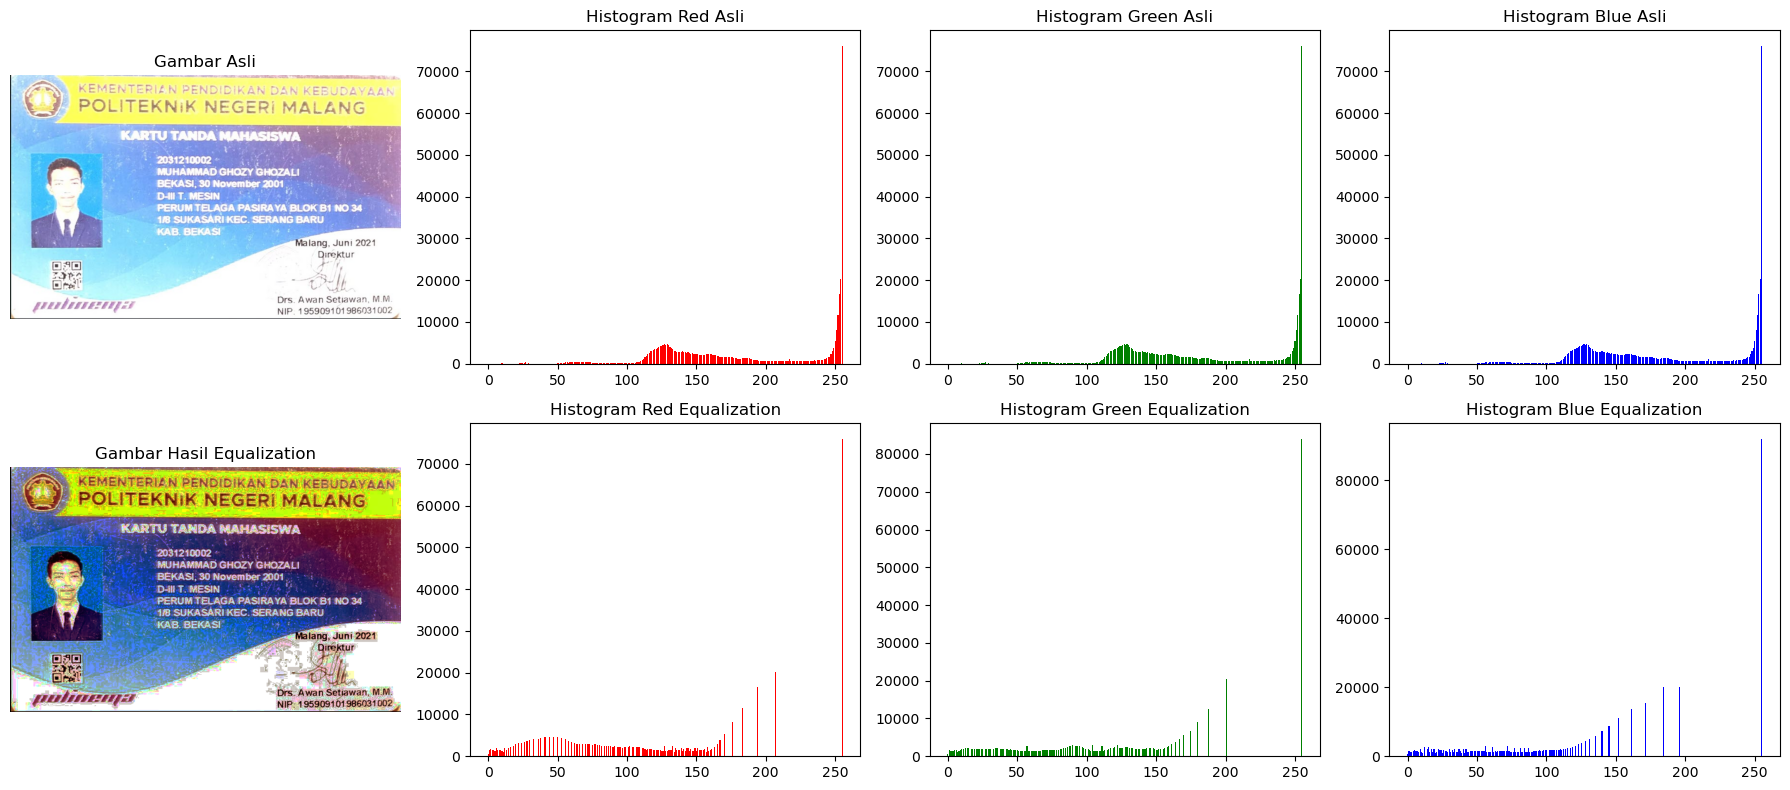

In [9]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

img_ktm = img_ktm = cv.imread('../images/KTM_lama.jpg')
img_ktm = cv.cvtColor(img_ktm, cv.COLOR_BGR2RGB)

r, g, b = cv.split(img_ktm)

r_eq = cv.equalizeHist(r)
g_eq = cv.equalizeHist(g)
b_eq = cv.equalizeHist(b)

img_ktm_eq = cv.merge((r_eq, g_eq, b_eq))

hist_r, bins_r = np.histogram(r.ravel(), 256, [0,256])
hist_g, bins_g = np.histogram(g.ravel(), 256, [0,256])
hist_b, bins_b = np.histogram(b.ravel(), 256, [0,256])

hist_r_eq, bins_r_eq = np.histogram(r_eq.ravel(), 256, [0,256])
hist_g_eq, bins_g_eq = np.histogram(g_eq.ravel(), 256, [0,256])
hist_b_eq, bins_b_eq = np.histogram(b_eq.ravel(), 256, [0,256])


fig, axs = plt.subplots(2, 4, figsize=(18,8))

axs[0,0].imshow(img_ktm)
axs[0,0].set_title("Gambar Asli")
axs[0,0].axis("off")

axs[0,1].bar(bins_r[:-1], hist_r, color='red')
axs[0,1].set_title("Histogram Red Asli")
axs[0,2].bar(bins_r[:-1], hist_r, color='green')
axs[0,2].set_title("Histogram Green Asli")
axs[0,3].bar(bins_r[:-1], hist_r, color='blue')
axs[0,3].set_title("Histogram Blue Asli")

axs[1,0].imshow(img_ktm_eq)
axs[1,0].set_title("Gambar Hasil Equalization")
axs[1,0].axis("off")

axs[1,1].bar(bins_r_eq[:-1], hist_r_eq, color='red')
axs[1,1].set_title("Histogram Red Equalization")
axs[1,2].bar(bins_g_eq[:-1], hist_g_eq, color='green')
axs[1,2].set_title("Histogram Green Equalization")
axs[1,3].bar(bins_b_eq[:-1], hist_b_eq, color='blue')    
axs[1,3].set_title("Histogram Blue Equalization")

plt.tight_layout()
plt.show()


#### c. Bandingkan citra KTM lama.jpg sebelum dan sesudah histogram equalization. Jelaskan perbedaan yang terlihat secara visual (misalnya pada detail wajah, teks, atau latar belakang). Apakah perubahan tersebut **meningkatkan kualitas informasi** dari citra atau justru membuat citra terlihat terlalu “keras”.

**Jawaban:** Pada gambar KTM_lama.jpg yang sudah di Equalization, gambar menjadi lebih kontras/detail dan mudah dilihat daripada gambar yang awal. Perubahan tersebut membuat peningkatan kualitas informasi dari citra namun citra jadi agak terlihat "keras".

# D-3 TUGAS PRAKTIKUM DITHERING

### 1. Lakukanlah proses dithering Floyd and Steinberg seperti output berikut (tampilan image awal, dan tampilan setelah dithering) berdasarkan flowchart di bagian bawah halaman modul ini! (Gunakan gambar lena.jpg)

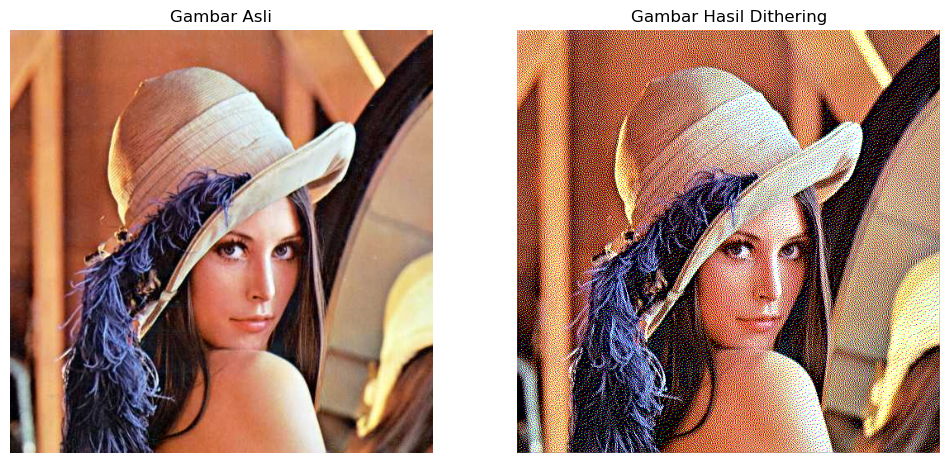

In [ ]:
# Input image
lena_img = lena_img = cv.imread("../images/lena.jpg")
lena_img = cv.cvtColor(lena_img, cv.COLOR_BGR2RGB)

img = lena_img.astype(np.float32).copy()
h, w, c = img.shape


def treshold(value):
    return 255 if value >= 128 else 0


for y in range(h - 1):
    for x in range(1, w - 1):
        for ch in range(c):
            old_pixel = img[y, x, ch]
            new_pixel = treshold(old_pixel)
            img[y, x, ch] = new_pixel
            error = old_pixel - new_pixel

            img[y, x + 1, ch] += error * 7 / 16
            img[y + 1, x - 1, ch] += error * 3 / 16
            img[y + 1, x, ch] += error * 5 / 16
            img[y + 1, x + 1, ch] += error * 1 / 16
            
img_dithered = np.clip(img, 0, 255).astype(np.uint8)

fig, axs = plt.subplots(1, 2, figsize=(12,6))
axs[0].imshow(lena_img)
axs[0].set_title("Gambar Lena Asli")
axs[0].axis("off")

axs[1].imshow(img_dithered)
axs[1].set_title("Gambar Lena Hasil Dithering")
axs[1].axis("off")
plt.show()

### 2. Menggunakan lena_lc.jpg rubah menjadi grey image, kemudian terapkan histogram equalization sehingga terjadi perbaikan sebaran warna pada citra. Setelah itu dari hasil histogram equalization implementasikan proses dithering Floyd and Steinberg sehingga menampilkan gambar di bawah ini!

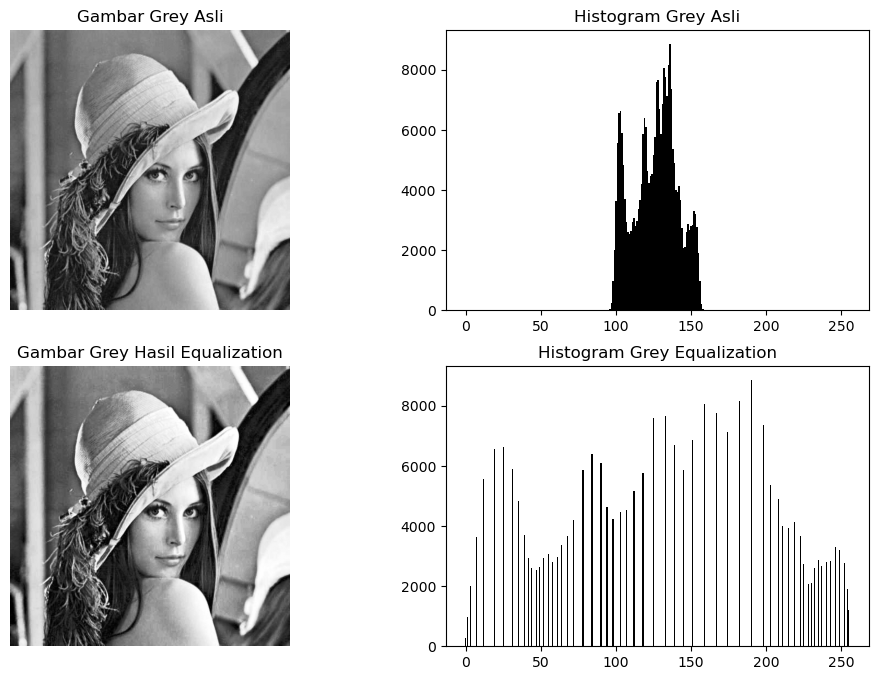

In [24]:
img_lena = img_lena = cv.imread('../images/lena_lc.jpg')
img_lena = cv.cvtColor(img_lena, cv.COLOR_BGR2RGB)

gray_img = cv.cvtColor(img_lena, cv.COLOR_RGB2GRAY)

# Histogram
hist, bins = np.histogram(gray_img.flatten(), 256, [0,256])

# Equalization
lena_equalized_img = cv.equalizeHist(gray_img)
hist_eq, bins_eq = np.histogram(lena_equalized_img.flatten(), 256, [0,256])

fig, axs = plt.subplots(2, 2, figsize=(12,8))
axs[0,0].imshow(gray_img, cmap='gray')
axs[0,0].set_title("Gambar Grey Asli")
axs[0,0].axis("off")
axs[0,1].bar(bins_eq[:-1], hist, color='black')
axs[0,1].set_title("Histogram Grey Asli")

axs[1,0].imshow(lena_equalized_img, cmap='gray')
axs[1,0].set_title("Gambar Grey Hasil Equalization")
axs[1,0].axis("off")
axs[1,1].bar(bins_eq[:-1], hist_eq, color='black')
axs[1,1].set_title("Histogram Grey Equalization")
plt.show()

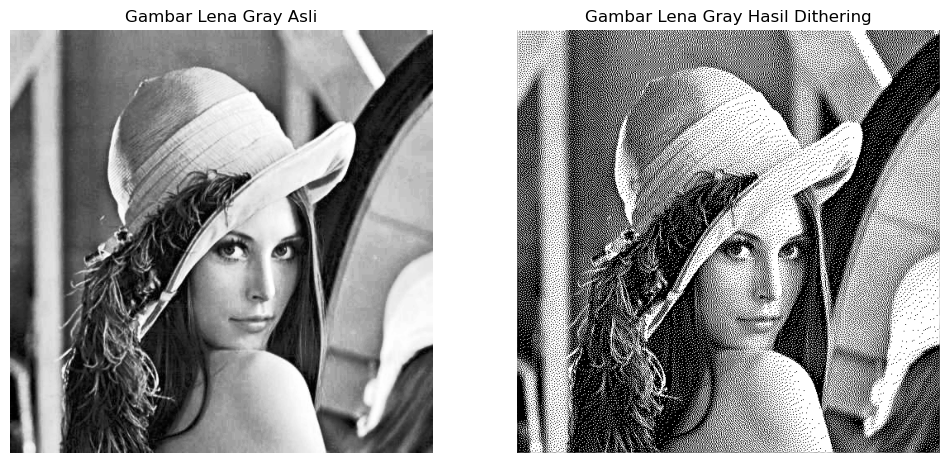

In [29]:
# Input image
lena_img = lena_equalized_img
lena_img = cv.cvtColor(lena_img, cv.COLOR_GRAY2RGB)

img = lena_img.astype(np.float32).copy()
h, w, c = img.shape


def treshold(value):
    return 255 if value >= 128 else 0


for y in range(h - 1):
    for x in range(1, w - 1):
        for ch in range(c):
            old_pixel = img[y, x, ch]
            new_pixel = treshold(old_pixel)
            img[y, x, ch] = new_pixel
            error = old_pixel - new_pixel

            img[y, x + 1, ch] += error * 7 / 16
            img[y + 1, x - 1, ch] += error * 3 / 16
            img[y + 1, x, ch] += error * 5 / 16
            img[y + 1, x + 1, ch] += error * 1 / 16
            
img_dithered = np.clip(img, 0, 255).astype(np.uint8)

fig, axs = plt.subplots(1, 2, figsize=(12,6))
axs[0].imshow(lena_img)
axs[0].set_title("Gambar Lena Gray Asli")
axs[0].axis("off")

axs[1].imshow(img_dithered)
axs[1].set_title("Gambar Lena Gray Hasil Dithering")
axs[1].axis("off")
plt.show()